Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.
Après avoir utilisé NumPy pour manipuler les données numériques et Pandas pour importer,
nettoyer et analyser le dataset, l'étape suivante consiste à représenter graphiquement les
informations afin d'identifier des tendances, des différences entre bâtiments et des anomalies.

**Partie 1 – Graphique linéaire (Line Plot)**

d'abord importation des données avec pandas 

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mesures_capteurs.csv")

**1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende
et la grille.**

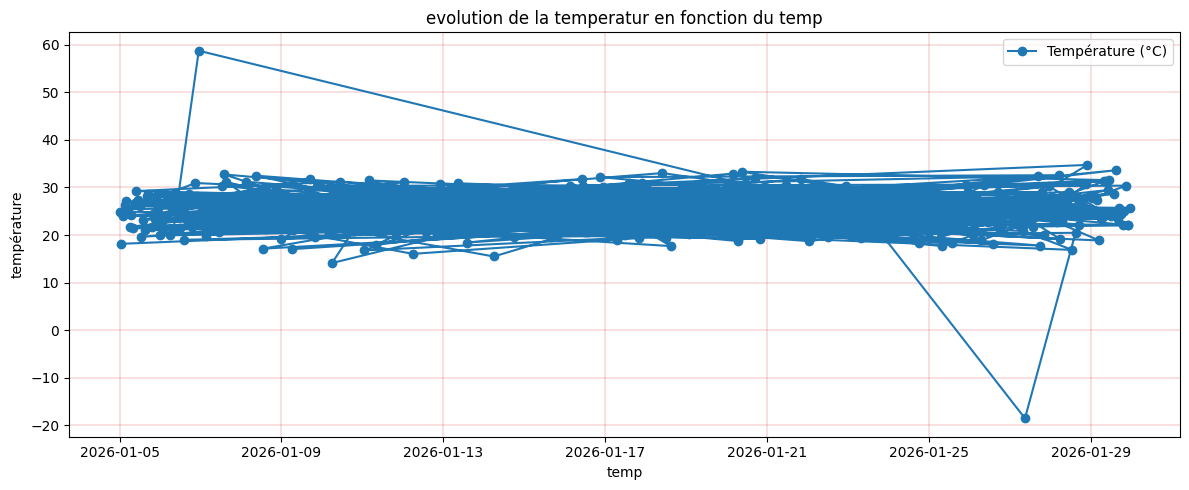

In [80]:
# alors pour afficher cette évolution il faut récuperer d'abord la colonne température et la colonne temp et aprés traçer le graphe
# alors moi j'utilise l'approche POO pour manipuler carrément tous
#donc avant tout j'ai d'abord convertit la colonne dat_heure en datetime pour uine plus pertinent format
#aprés j'ai utilisé le syntaxe de la POO pour ploter la température et la date et ajouter un tire et les deux labels(x&y) ajouter le grid et enfin afficher
#et ajout du label dans le plot et l'appelé avec legend
x= pd.to_datetime(df["date_heure"])
y= df["temperature"]

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(x,y,marker='o',label="Température (°C)")

ax.set_title("evolution de la temperatur en fonction du temp")
ax.set_xlabel("temp")
ax.set_ylabel("température")

ax.grid(True, color="tab:red", linewidth=0.2)
plt.tight_layout()
plt.legend()
plt.show()

**Anomalies visibles :** alors ici on observe quelques pics ponctuels qui sortent nettement du nuage principal de
points (qui oscille grossièrement entre 15 °C et 35 °C) — notamment une valeur très basse
proche de -18 °C et une valeur très haute proche de 58 °C. Ces points isolés, physiquement peu
plausibles pour une température, représente probablement des erreurs de capteur.

**1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments**

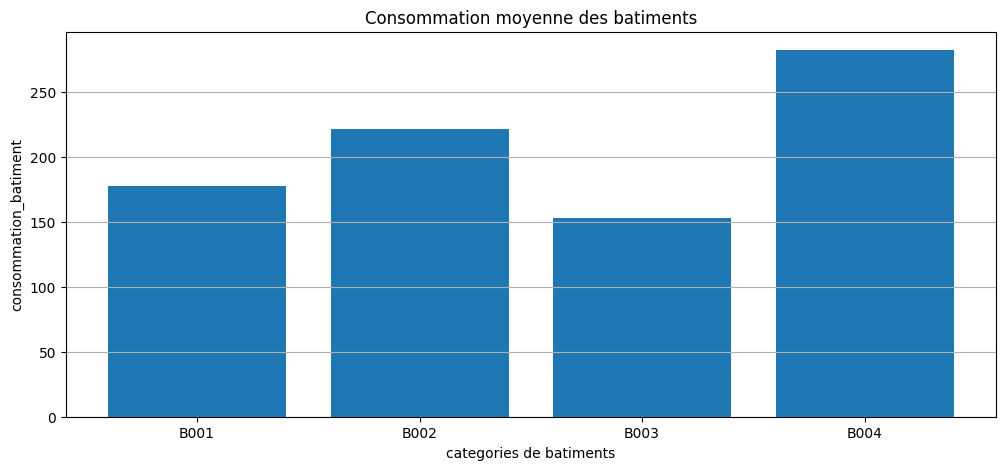

In [81]:
cons_batiment = df.groupby("batiment")["consommation"].mean()

cons_batiment.index # maitenant ce sera nos categorie
cons_batiment # et là nous aurons nos vaaleurs

fig, ax=plt.subplots(figsize=(12,5))

plt.bar(cons_batiment.index,cons_batiment)
ax.set_title("Consommation moyenne des batiments")
ax.set_xlabel("categories de batiments")
ax.set_ylabel("consommation_batiment")
plt.grid(axis="y") #pour faire les grid dans l'axe des ordonnées

plt.show()


**2) Comparer graphiquement la consommation moyenne des bâtiments**

B002 et B004 consomment au-dessus de la moyenne, B004 étant nettement le plus énergivore du groupe.
B001 et B003 sont en dessous, B003 étant le plus économe.
L'écart entre le bâtiment le plus et le moins consommateur est au alentours de 130 unités, ce qui est trés significatif — ça vaut le coup de creuser pourquoi B004 consomme.

**3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal**

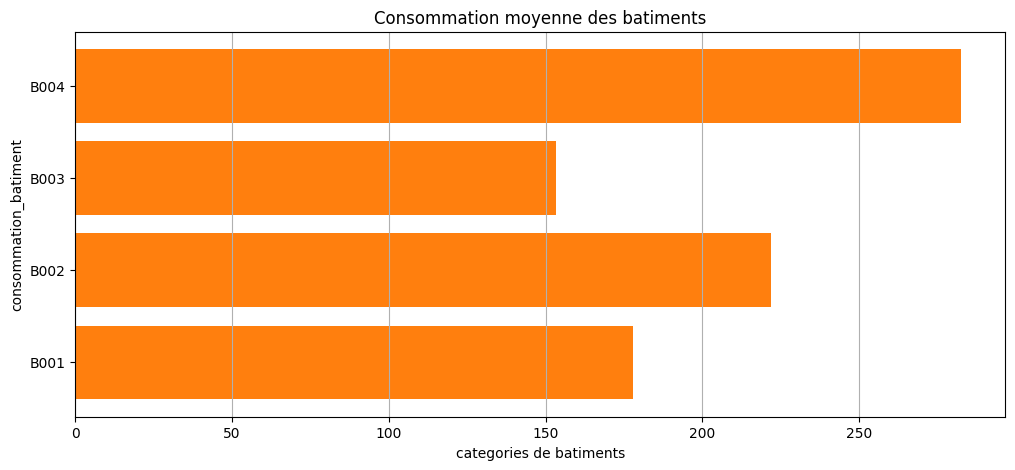

In [82]:
cons_batiment = df.groupby("batiment")["consommation"].mean()

cons_batiment.index # maitenant ce sera nos categorie
cons_batiment # et là nous aurons nos vaaleurs

fig, ax=plt.subplots(figsize=(12,5))

plt.barh(cons_batiment.index,cons_batiment,color="tab:orange")
ax.set_title("Consommation moyenne des batiments")
ax.set_xlabel("categories de batiments")
ax.set_ylabel("consommation_batiment")
plt.grid(axis="x") #pour faire les grid dans l'axe des abcisses

plt.show()

**Quand un graphique horizontal est-il plus lisible ?** Dès que les noms des catégories
sont longs (ils ne se chevauchent pas et n'ont pas besoin d'être inclinés), quand il y a
beaucoup de catégories à lister (plus confortable à lire de haut en bas), ou quand on veut
présenter un classement, car l'œil lit naturellement une liste de haut en bas comme un
classement.

**Partie 3 – Histogramme**

**1) Afficher la distribution des températures en divisant la plage des données en 20 classes et en
affichant uniquement les lignes horizontales de la grille**

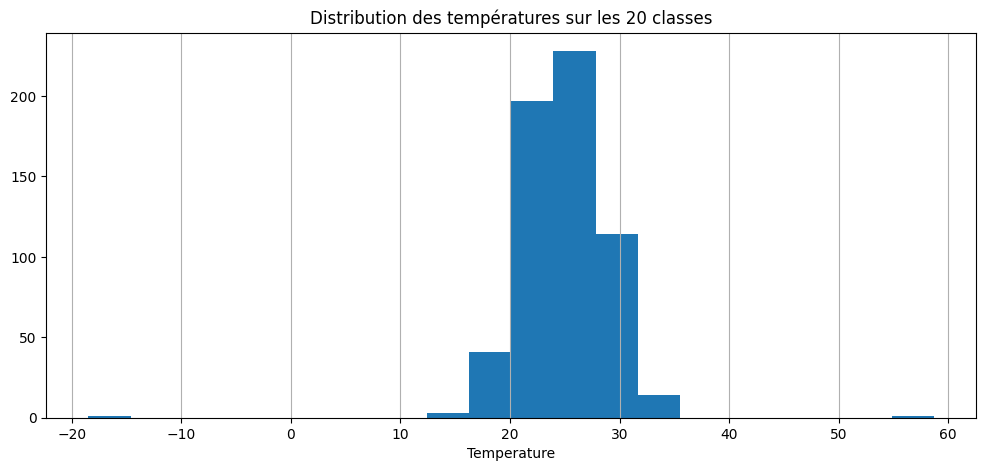

In [83]:
fig, ax=plt.subplots(figsize=(12,5))

#alors pour traçer un histogramme nous avons juste besoins de la catégorie et du nombre de classe (la plage)
plt.hist(df["temperature"], bins=20)
ax.set_title("Distribution des températures sur les 20 classes")
ax.set_xlabel("Temperature")
plt.grid(axis="x") #pour faire les grid dans l'axe des abcisses

plt.show()

**2) Analyse du graphique :**


**a) Pour la concentration** : la majorité des mesures se regroupe entre 20 °C et 30 °C, autour d'une
  classe centrale la plus fréquente proche de 24-25 °C.

**b) La symétrie** : la distribution paraît globalement assez symétrique autour de son pic central,
  en forme de cloche.

**c) Les valeurs éloignées** : quelques barres isolées, très basses en hauteur, apparaissent loin à
  gauche (vers -18 °C) et loin à droite (vers 58 °C).

**d) Les valeurs aberrantes** : ces barres isolées, séparées du reste par des classes vides,
  correspondent aux anomalies déjà repérées dans le graphique linéaire de la Partie 1.

**3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes**

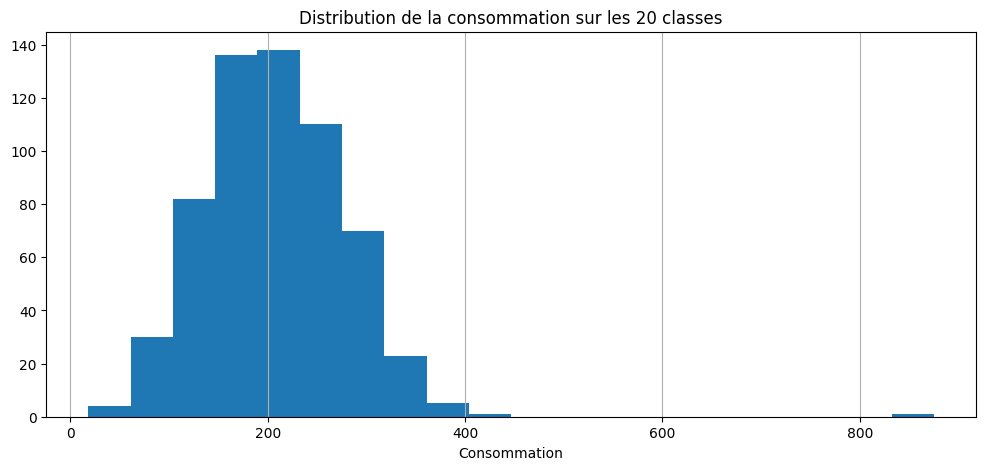

In [84]:
fig, ax=plt.subplots(figsize=(12,5))

#alors pour traçer un histogramme nous avons juste besoins de la catégorie et du nombre de classe (la plage)
plt.hist(df["consommation"], bins=20)
ax.set_title("Distribution de la consommation sur les 20 classes")
ax.set_xlabel("Consommation")
plt.grid(axis="x") #pour faire les grid dans l'axe des abcisses

plt.show()

**a) Modification du nombre de classes à 10**

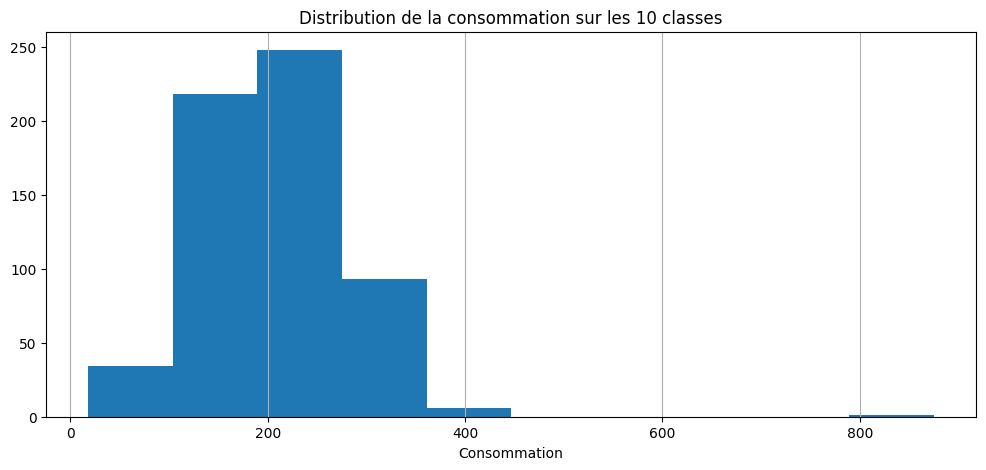

In [85]:
fig, ax=plt.subplots(figsize=(12,5))

#alors pour traçer un histogramme nous avons juste besoins de la catégorie et du nombre de classe (la plage)
plt.hist(df["consommation"], bins=10)
ax.set_title("Distribution de la consommation sur les 10 classes")
ax.set_xlabel("Consommation")
plt.grid(axis="x") #pour faire les grid dans l'axe des abcisses

plt.show()

**b) Modification du nombre de classes à 30**

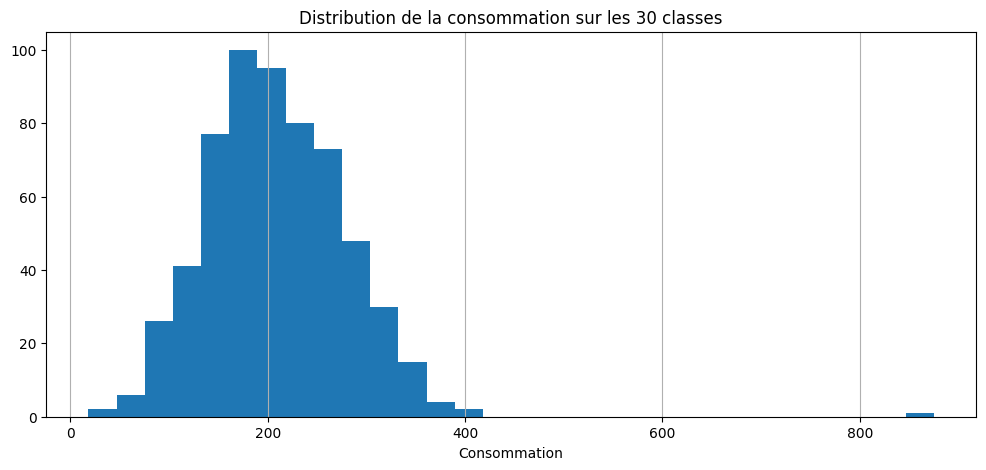

In [86]:
fig, ax=plt.subplots(figsize=(12,5))

#alors pour traçer un histogramme nous avons juste besoins de la catégorie et du nombre de classe (la plage)
plt.hist(df["consommation"], bins=30)
ax.set_title("Distribution de la consommation sur les 30 classes")
ax.set_xlabel("Consommation")
plt.grid(axis="x") #pour faire les grid dans l'axe des abcisses

plt.show()

**c) l'impact qu'a le nombre de classes sur l'interprétation :**

Avec les **10 classes**, les barres sont larges et
la distribution est lissée.On voit la tendance générale mais on perd le détail. Avec **30
classes**, les barres sont fines et on distingue davantage de variations locales, mais le
graphique devient plus « bruité » et certaines classes contiennent trop peu de mesures pour
être fiables. Il faut donc un compromis : trop peu de classes cache l'information, trop de
classes noie l'information dans du bruit statistique.de ce fait le nombre de classe qui nous sort les informations les plus pertinentes sans beaucoup d'ambiguité est la plage avec **20 classe**

**Partie 4 – Nuage de points (Scatter Plot)**

**1) Réaliser un nuage de points entre température et consommation**

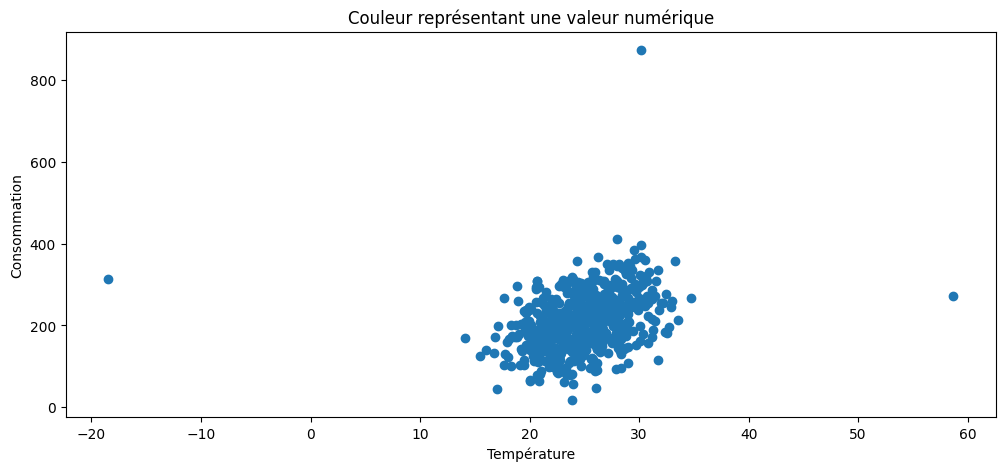

In [87]:
#on utilise le mot scatter pour créer un nuage de point entre deux variables

fig, ax = plt.subplots(figsize=(12,5))

ax.scatter(df["temperature"],df["consommation"])

ax.set_title("Couleur représentant une valeur numérique")
ax.set_xlabel("Température")
ax.set_ylabel("Consommation")

plt.show()

**2) Déterminer visuellement s'il semble exister une relation entre les deux**

le nuage de points est assez étalé, mais on distingue tout de même une légère tendance : plus la température augmente, plus la consommation a tendance à être élevée en moyenne (le nuage "monte" doucement vers la droite). La relation reste faible et bruitée — beaucoup de points s'écartent largement de cette tendance mais elle n'est pas totalement nulle.

**Partie 6 – Diagramme circulaire (Pie Chart)**

1) Créer un box plot de la température. N’oublier pas de supprimer les valeurs manquantes avant
de construire le graphique et afficher uniquement les lignes horizontales de la grille

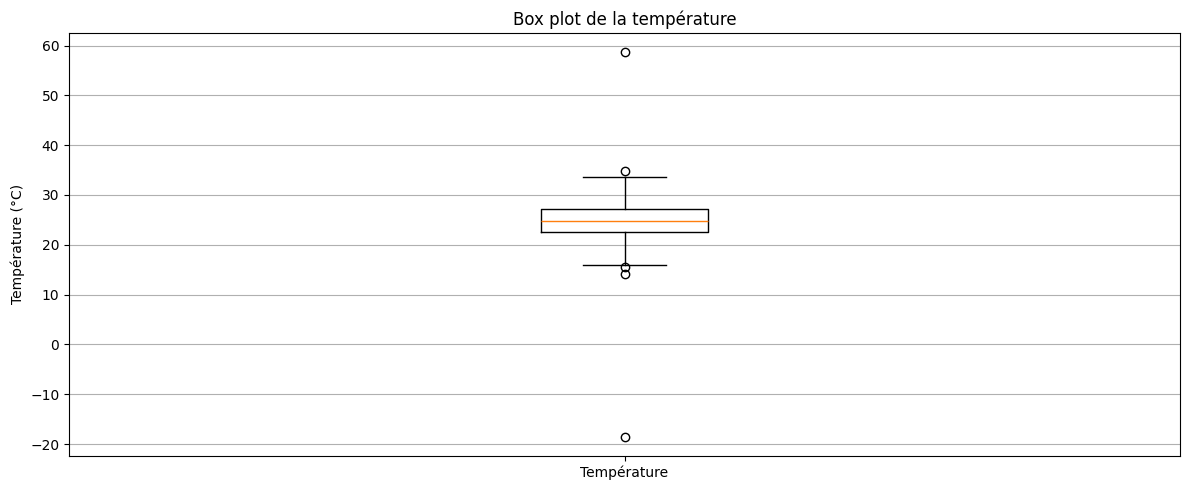

In [88]:
#alors ici on utilise ax.boxplot() qui attend une série sans valeurs manquantes, d'où le .dropna()
#avant de le construire. `ax.grid(axis="y")` n'affiche que les lignes horizontales.
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(df["temperature"].dropna(), tick_labels=["Température"])
ax.set_title("Box plot de la température")
ax.set_ylabel("Température (°C)")
ax.grid(axis="y")
fig.tight_layout()
plt.show()

**2) Que représentent les points situés en dehors des moustaches**

**Les points en dehors des moustaches** sont les valeurs considérées comme atypiques
(outliers) par la règle statistique du box plot — des mesures trop éloignées du reste de la
distribution (au-delà de 1,5 fois l'écart interquartile). Ce sont les mêmes anomalies déjà
repérées dans les Parties 1 et 3.

**3) Créer un box plot de la consommation**

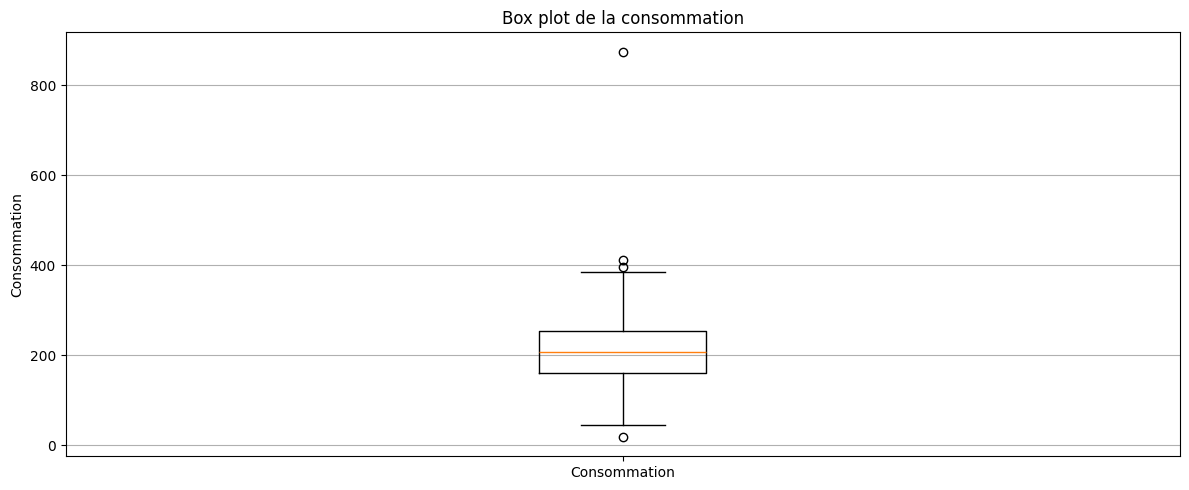

In [89]:
#de la méme maniére que la précendente on utilise dropna() pour supprimer les valeurs manquant et boxplot() pour avoir ce graphe

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(df["consommation"].dropna(), tick_labels=["Consommation"])
ax.set_title("Box plot de la consommation")
ax.set_ylabel("Consommation")
ax.grid(axis="y")
fig.tight_layout()
plt.show()

**4) A partir des deux box plot, comparons :**

**a) la position de la médiane**

les deux médianes se situent à peu près au centre de leur boîte, signe de
distributions relativement équilibrées.

**b) la taille de la boîte**

(écart interquartile) : la boîte de la consommation est nettement
plus grande que celle de la température — la consommation varie davantage d'une mesure à
l'autre.

**c) la longueur des moustaches**

les moustaches de la consommation sont également plus longues que celle de la température.

**d) les valeurs extrêmes**

la température présente quelques outliers très marqués, alors que
la consommation en présente peu, voire aucun.

**5) La consommation présente-t-elle davantage de dispersion que la température**

la consommation présente une dispersion globale plus grande que la
température, même si c'est la température qui possède les valeurs individuelles les plus
extrêmes (outliers).

**Partie 5 – Diagramme à moustache (Box plot)**

**1) Réaliser un diagramme pour analyser la répartition des états (OK, ALERTE, ERREUR)**

on compte le nombre de mesures pour chaque état avec
`value_counts()`, puis `ax.pie()` affiche les proportions avec les pourcentages
(`autopct`).

In [90]:
etat_counts = df["etat"].dropna().value_counts()
etat_counts

etat
OK        567
ALERTE     29
ERREUR      5
Name: count, dtype: int64

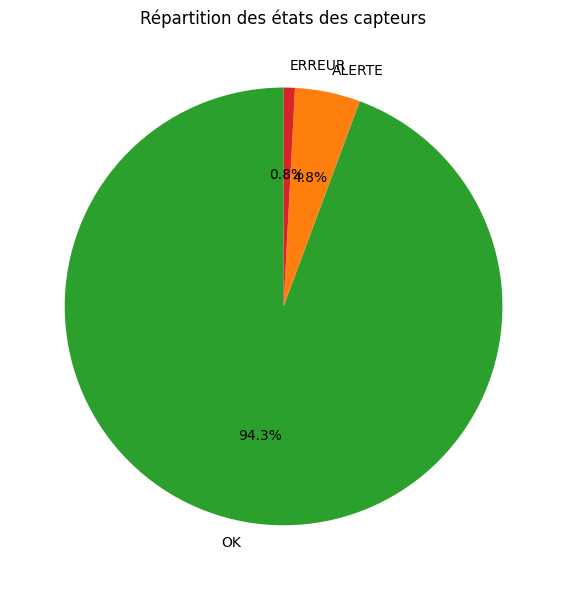

In [94]:
#on trace le graphe à parti des données récupérées en haut
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    etat_counts.values,
    labels=etat_counts.index,
    autopct="%1.1f%%",
    colors=["tab:green", "tab:orange", "tab:red"],
    startangle=90,
)
ax.set_title("Répartition des états des capteurs")
fig.tight_layout()
plt.show()

2) interpréter la proportion de capteurs OK ; proportion ALERTE ; proportion ERREUR

on constate la grande majorité des capteurs sont à l'état **OK**, ce qui est
rassurant sur la santé globale du parc de capteurs. Les états **ALERTE** et **ERREUR**
représentent chacun une part beaucoup plus faible, l'ERREUR étant à traiter en priorité.